## **DBSCAN Clustering**

### **Topic Roadmap**

**1. Create a non-linear dataset**

**2. Fit DBSCAN**

**3. Identify core points and noise**

**4. Compare parameter settings**

**5. Key revision notes**

## **1. Non-Linear Dataset**

DBSCAN groups dense connected regions and can identify noise. No cluster-count input is required.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
X, _ = make_moons(n_samples=800, noise=0.08, random_state=RANDOM_STATE)
X = StandardScaler().fit_transform(X)

## **2. Fit DBSCAN**

`eps` is the neighborhood radius. `min_samples` is the minimum number of points needed for a dense neighborhood. Label `-1` denotes noise.

In [7]:
dbscan = DBSCAN(eps=0.25, min_samples=8)
labels = dbscan.fit_predict(X)
unique_labels = sorted(set(labels))
print("Labels:", unique_labels)
print("Noise points:", np.sum(labels == -1))

Labels: [np.int64(0), np.int64(1)]
Noise points: 0


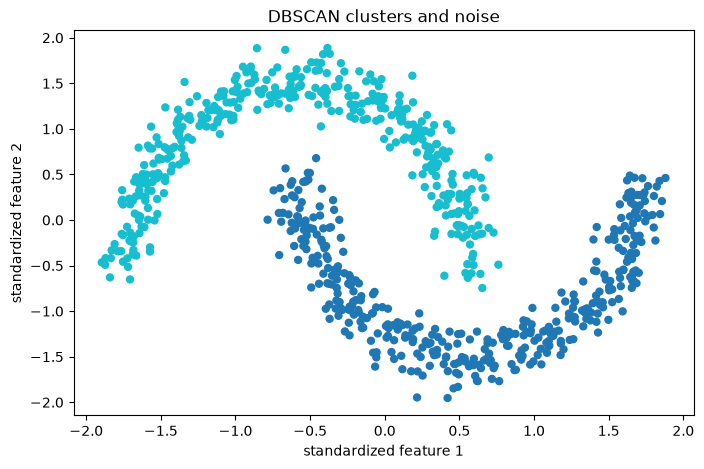

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=25)
plt.title("DBSCAN clusters and noise")
plt.xlabel("standardized feature 1")
plt.ylabel("standardized feature 2")
plt.show()

## **3. Inspect Core Samples and Silhouette Score**

Core samples satisfy the density requirement. Silhouette score is calculated only on clustered points when noise is present.

In [9]:
print("Core samples:", dbscan.core_sample_indices_.size)
clustered = labels != -1
if len(set(labels[clustered])) > 1:
    print("Silhouette score without noise:", silhouette_score(X[clustered], labels[clustered]))

Core samples: 788
Silhouette score without noise: 0.3863359696192401


## **4. Parameter Sensitivity**

DBSCAN is sensitive to feature scale and neighborhood radius. A small comparison shows how `eps` changes the number of discovered clusters.

In [10]:
comparison = []
for eps in [0.15, 0.20, 0.25, 0.30, 0.40]:
    candidate_labels = DBSCAN(eps=eps, min_samples=8).fit_predict(X)
    cluster_count = len(set(candidate_labels)) - (1 if -1 in candidate_labels else 0)
    comparison.append({"eps": eps, "clusters": cluster_count, "noise_points": int(np.sum(candidate_labels == -1))})
pd.DataFrame(comparison)

,eps,clusters,noise_points
0,0.15,3,26
1,0.20,2,4
2,0.25,2,0
3,0.30,2,0
4,0.40,1,0


### **Key Revision Notes**

- DBSCAN defines clusters through density connectivity.
- `eps` and `min_samples` control what counts as dense.
- Label `-1` is noise, not a regular cluster.
- DBSCAN can find non-convex clusters and does not require `n_clusters` in advance.